# Step 2. 전처리 — 결측치 처리 · 분산 0 제거 · SMOTE · Train/Test 분리

**목표**: EDA에서 확인한 데이터 품질 이슈(결측치, 상수 센서, 클래스 불균형)를 정제해 모델 학습용 데이터를 만든다.

**핵심 원칙 — 데이터 누수(leakage) 방지**
> 모든 전처리(결측 컬럼 제거 기준, median 값, 분산 0 판정, SMOTE)는 **train 데이터에서만 fit**하고 test에는 그대로 적용(transform)만 한다.
> 특히 **SMOTE는 train에만** 적용한다. test에 합성 샘플이 섞이면 성능이 부풀려진다.

**처리 순서**
1. 데이터 로드 → Train/Test 분리 (8:2, stratify)
2. 결측치 50% 이상 컬럼 제거 (train 기준)
3. 나머지 결측치 median imputation (train 기준)
4. 분산 0 피처 제거 (VarianceThreshold, train 기준)
5. SMOTE로 train 클래스 불균형 처리
6. 처리 결과 저장 (`data/processed/`)

## 0. 환경 설정 및 데이터 로드

In [1]:
# 라이브러리 import
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import VarianceThreshold
from imblearn.over_sampling import SMOTE

# 한글 폰트 설정 (seaborn 스타일을 먼저 적용한 뒤 폰트 지정 — 덮어쓰기 방지)
sns.set_style('whitegrid')
mpl.rcParams['font.family'] = 'AppleGothic'
mpl.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 110

DATA_DIR = os.path.join('..', 'data')
FIG_DIR = os.path.join('..', 'outputs', 'figures')
PROC_DIR = os.path.join('..', 'data', 'processed')
os.makedirs(PROC_DIR, exist_ok=True)

RANDOM_STATE = 42  # 재현성을 위한 고정 시드
print('준비 완료')

준비 완료


In [2]:
# 원본 데이터 로드 (Step 1과 동일)
X = pd.read_csv(os.path.join(DATA_DIR, 'secom.data'),
                sep=' ', header=None, na_values='NaN')
X.columns = [f'sensor_{i:03d}' for i in range(X.shape[1])]

labels = pd.read_csv(os.path.join(DATA_DIR, 'secom_labels.data'),
                     sep=' ', header=None, names=['label_raw', 'timestamp'])
y = labels['label_raw'].map({-1: 0, 1: 1}).rename('target')  # 1=불량

print('원본 X:', X.shape, '| y 불량 비율: %.2f%%' % (y.mean()*100))

원본 X: (1567, 590) | y 불량 비율: 6.64%


## 1. Train/Test 분리 (8:2, stratify)

전처리보다 **분리를 먼저** 수행한다. 그래야 이후 모든 전처리 기준을 train에서만 학습해 test 정보가 새지 않는다.
불량 비율이 낮으므로 `stratify=y`로 train/test의 클래스 비율을 동일하게 맞춘다.

In [3]:
# 8:2 분리 + 층화추출(stratify)로 불량 비율 유지
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

print(f'Train: {X_train.shape}, 불량 {y_train.sum()}개 ({y_train.mean()*100:.2f}%)')
print(f'Test : {X_test.shape}, 불량 {y_test.sum()}개 ({y_test.mean()*100:.2f}%)')

Train: (1253, 590), 불량 83개 (6.62%)
Test : (314, 590), 불량 21개 (6.69%)


## 2. 결측치 50% 이상 컬럼 제거

제거 기준이 되는 결측 비율은 **train에서만** 계산한다. 동일하게 식별된 컬럼을 train/test 양쪽에서 제거한다.

In [4]:
# train 기준 컬럼별 결측 비율 계산 → 50% 이상이면 제거 대상
train_missing = X_train.isna().mean()
high_missing_cols = train_missing[train_missing >= 0.5].index.tolist()

X_train = X_train.drop(columns=high_missing_cols)
X_test = X_test.drop(columns=high_missing_cols)  # train에서 정한 동일 컬럼 제거

print(f'결측치 50%↑ 제거 컬럼: {len(high_missing_cols)}개')
print(f'남은 피처: {X_train.shape[1]}개')

결측치 50%↑ 제거 컬럼: 24개
남은 피처: 566개


## 3. 결측치 median imputation

남은 결측치는 중앙값(median)으로 대체한다. 센서 값에 이상치가 섞여 있을 수 있어 평균보다 median이 안정적이다.
`SimpleImputer`를 **train으로 fit**하고 그 median을 test에 그대로 적용한다.

In [5]:
# median imputer: train으로 fit → train/test 모두 transform
feature_names = X_train.columns.tolist()
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)
X_test_imp = imputer.transform(X_test)

print('결측치 대체 후 NaN 개수 (train/test):',
      np.isnan(X_train_imp).sum(), '/', np.isnan(X_test_imp).sum())

결측치 대체 후 NaN 개수 (train/test): 0 / 0


## 4. 분산 0 피처 제거 (VarianceThreshold)

EDA에서 확인한 상수(분산 0) 센서는 불량 구분에 기여하지 못하므로 제거한다. 임계값 0 = 완전 상수만 제거.

In [6]:
# 분산 0 피처 제거: train으로 fit → 동일 마스크를 test에 적용
selector = VarianceThreshold(threshold=0.0)
X_train_var = selector.fit_transform(X_train_imp)
X_test_var = selector.transform(X_test_imp)

# 살아남은 피처 이름 추적 (이후 SHAP 해석에서 센서명 매핑에 사용)
kept_mask = selector.get_support()
feature_names = [f for f, keep in zip(feature_names, kept_mask) if keep]

print(f'분산 0 제거 컬럼: {(~kept_mask).sum()}개')
print(f'최종 피처 수: {X_train_var.shape[1]}개')

분산 0 제거 컬럼: 116개
최종 피처 수: 450개


## 5. SMOTE로 클래스 불균형 처리 (train 전용)

불량(소수 클래스)을 합성 오버샘플링으로 늘려 1:1에 가깝게 맞춘다.
**반드시 train에만 적용** — test는 실제 분포(불량 6.6%)를 유지해야 일반화 성능을 정직하게 평가할 수 있다.

SMOTE 전 train 클래스 분포: [1170   83]
SMOTE 후 train 클래스 분포: [1170 1170]
train 샘플 수: 1253 → 2340


/Users/kimmilim/Desktop/미림/2026-1/SK하이닉스_중반기/반도체플젝/.venv/lib/python3.9/site-packages/sklearn/base.py:474: FutureWarning: `BaseEstimator._validate_data` is deprecated in 1.6 and will be removed in 1.7. Use `sklearn.utils.validation.validate_data` instead. This function becomes public and is part of the scikit-learn developer API.
  warnings.warn(


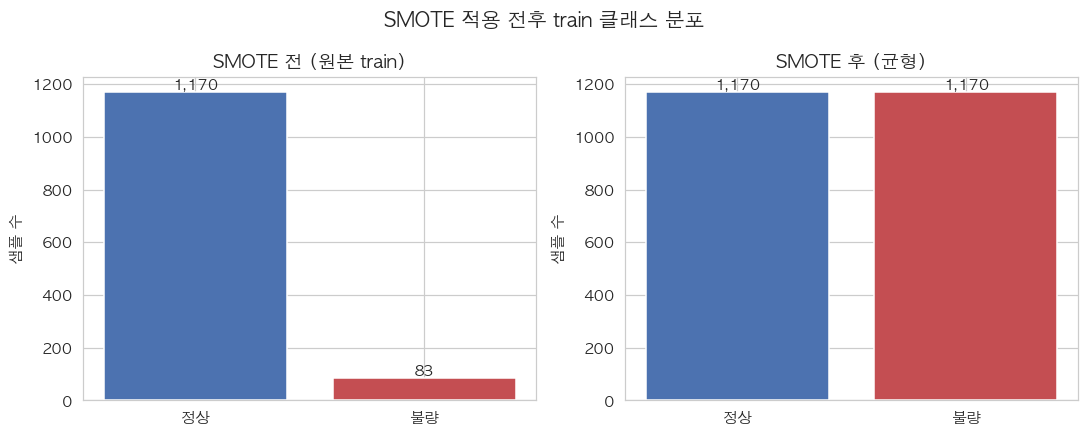

In [7]:
# SMOTE는 train에만 적용 (test는 손대지 않음)
smote = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = smote.fit_resample(X_train_var, y_train)

print('SMOTE 전 train 클래스 분포:', np.bincount(y_train))
print('SMOTE 후 train 클래스 분포:', np.bincount(y_train_res))
print(f'train 샘플 수: {len(y_train)} → {len(y_train_res)}')

# SMOTE 전/후 클래스 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (data, title) in zip(
        axes, [(y_train, 'SMOTE 전 (원본 train)'), (y_train_res, 'SMOTE 후 (균형)')]):
    vc = pd.Series(data).value_counts().sort_index()
    bars = ax.bar(['정상', '불량'], vc.values, color=['#4C72B0', '#C44E52'])
    for b, c in zip(bars, vc.values):
        ax.text(b.get_x()+b.get_width()/2, c, f'{c:,}', ha='center', va='bottom')
    ax.set_title(title)
    ax.set_ylabel('샘플 수')
fig.suptitle('SMOTE 적용 전후 train 클래스 분포', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, '04_smote_balance.png'), bbox_inches='tight')
plt.show()

## 6. 처리 결과 저장

모델링 단계(`03_modeling.ipynb`)에서 바로 불러올 수 있도록 저장한다.
- `X_train_res, y_train_res`: SMOTE 적용된 학습용 데이터
- `X_test, y_test`: 원본 분포를 유지한 평가용 데이터
- `feature_names`: 살아남은 센서명 (SHAP 해석에 사용)

In [8]:
# npz 하나로 묶어 저장 (배열 + 피처명)
# - SMOTE 적용 train(X_train/y_train): 최종 모델 학습용
# - SMOTE 이전 정제 train(X_train_clean/y_train_clean): Step3에서 임계값을 교차검증으로
#   정할 때 사용 (SMOTE를 CV 파이프라인 안에 넣어 누수 없이 튜닝하기 위함)
save_path = os.path.join(PROC_DIR, 'secom_processed.npz')
np.savez_compressed(
    save_path,
    X_train=X_train_res, y_train=y_train_res.to_numpy(),
    X_train_clean=X_train_var, y_train_clean=y_train.to_numpy(),
    X_test=X_test_var, y_test=y_test.to_numpy(),
    feature_names=np.array(feature_names),
)
print('저장 완료:', save_path)
print(f'  X_train(SMOTE) : {X_train_res.shape}')
print(f'  X_train_clean  : {X_train_var.shape} (SMOTE 전, 임계값 튜닝용)')
print(f'  X_test         : {X_test_var.shape}')
print(f'  feature_names  : {len(feature_names)}개')

저장 완료: ../data/processed/secom_processed.npz
  X_train(SMOTE) : (2340, 450)
  X_train_clean  : (1253, 450) (SMOTE 전, 임계값 튜닝용)
  X_test         : (314, 450)
  feature_names  : 450개


## 7. 전처리 요약

In [9]:
print('=' * 52)
print('  SECOM 전처리 요약')
print('=' * 52)
print(f'• 원본 피처 590 → 결측50%↑ 제거 → 분산0 제거 → 최종 {len(feature_names)}개')
print(f'• Train/Test 분리   : 8:2 (stratify, seed={RANDOM_STATE})')
print(f'• 결측치 처리       : median imputation (train fit)')
print(f'• SMOTE             : train만 적용 → {np.bincount(y_train_res)[0]}:{np.bincount(y_train_res)[1]} 균형')
print(f'• Test 불량 비율    : {y_test.mean()*100:.2f}% (원본 분포 유지)')
print('=' * 52)

  SECOM 전처리 요약
• 원본 피처 590 → 결측50%↑ 제거 → 분산0 제거 → 최종 450개
• Train/Test 분리   : 8:2 (stratify, seed=42)
• 결측치 처리       : median imputation (train fit)
• SMOTE             : train만 적용 → 1170:1170 균형
• Test 불량 비율    : 6.69% (원본 분포 유지)


### 포트폴리오용 인사이트 (Step 2)

- **누수 없는 파이프라인 설계**: split을 가장 먼저 수행하고 결측 기준·median·분산판정·SMOTE를 모두 train에서만 학습했다. 실무에서 "검증 성능이 부풀려지는" 흔한 실수를 의식적으로 차단한 점이 핵심.
- **SMOTE는 train 전용**: test는 실제 불량 비율(6.6%)을 유지해야 모델이 현장에서 마주할 분포에서의 성능을 정직하게 평가할 수 있다.
- **피처 정제**: 정보가 거의 없는 고결측·상수 센서를 제거해 모델이 의미 있는 공정 변수에 집중하도록 했다 (이후 SHAP 해석의 신뢰도와 직결).

**→ 다음 단계: `03_modeling.ipynb` (RandomForest 베이스라인 → XGBoost, Recall/F1/ROC-AUC 평가)**